# Teen Mental Health & Lifestyle Habits Analysis

This project explores a dataset of teen mental health metrics and lifestyle habits. We investigate how factors like social media usage, sleep, physical activity, and screen time relate to mental health outcomes such as stress, anxiety, addiction, and depression.

**Workflow:**
1. Data inspection, cleaning, and exploratory analysis
2. SQL-based structured querying
3. Machine learning to predict stress levels
4. Composite "Unhealthy Score" analysis to identify the most damaging habits
5. Model comparison and interactive prediction tools

---
# Part 1: Data Understanding

## 1. Raw Data Inspection
First, we load the dataset and inspect its structure, data types, and basic statistics to understand what we are working with.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Load the dataset
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

# Display the first few rows
print('--- First 5 Rows ---')
display(df.head())

# Inspect data types and non-null counts
print('\n--- Dataset Info ---')
df.info()

# Summary statistics
print('\n--- Summary Statistics ---')
display(df.describe(include='all'))

--- First 5 Rows ---


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0



--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200.000000
unique,NaN,2,NaN,3,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN
top,NaN,male,NaN,Instagram,NaN,NaN,NaN,NaN,medium,NaN,NaN,NaN,NaN
freq,NaN,615,NaN,411,NaN,NaN,NaN,NaN,416,NaN,NaN,NaN,NaN
mean,15.928333,NaN,4.536667,NaN,6.449417,1.740333,2.990383,1.014500,NaN,5.445833,5.636667,5.565000,0.025833
std,2.021947,NaN,2.029599,NaN,1.442677,0.716660,0.576758,0.582185,NaN,2.903290,2.859453,2.830627,0.158704
min,13.000000,NaN,1.000000,NaN,4.000000,0.500000,2.000000,0.000000,NaN,1.000000,1.000000,1.000000,0.000000
25%,14.000000,NaN,2.800000,NaN,5.200000,1.100000,2.500000,0.500000,NaN,3.000000,3.000000,3.000000,0.000000
50%,16.000000,NaN,4.500000,NaN,6.500000,1.800000,2.990000,1.000000,NaN,5.000000,6.000000,6.000000,0.000000
75%,18.000000,NaN,6.300000,NaN,7.600000,2.400000,3.480000,1.500000,NaN,8.000000,8.000000,8.000000,0.000000


## 2. Data Cleaning and Preprocessing
We need to ensure missing values are handled correctly. We will convert any hidden string representations of missing values (like 'NaN' or 'N/A') into true `np.nan` values, then check our missing value counts.

In [2]:
# Replace common string representations of missing values with true np.nan
df.replace(['NaN', 'nan', 'N/A', 'NA', 'null', '?', ''], np.nan, inplace=True)

# Check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if missing_values.empty:
    print('Dataset is clean: No missing values found!')
else:
    print('Missing values found:\n')
    display(missing_values.to_frame(name='Missing Count'))

Dataset is clean: No missing values found!


## 3. Feature Exploration and Visualization
Let's visualize the distribution of key variables, check correlations between numeric features, and compare categorical groups.

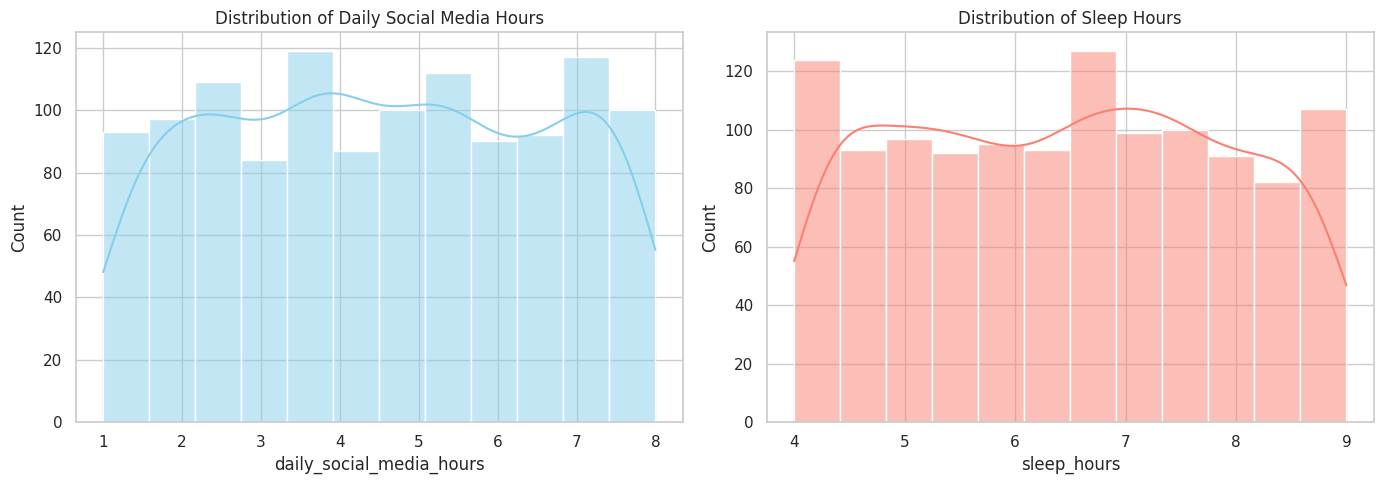

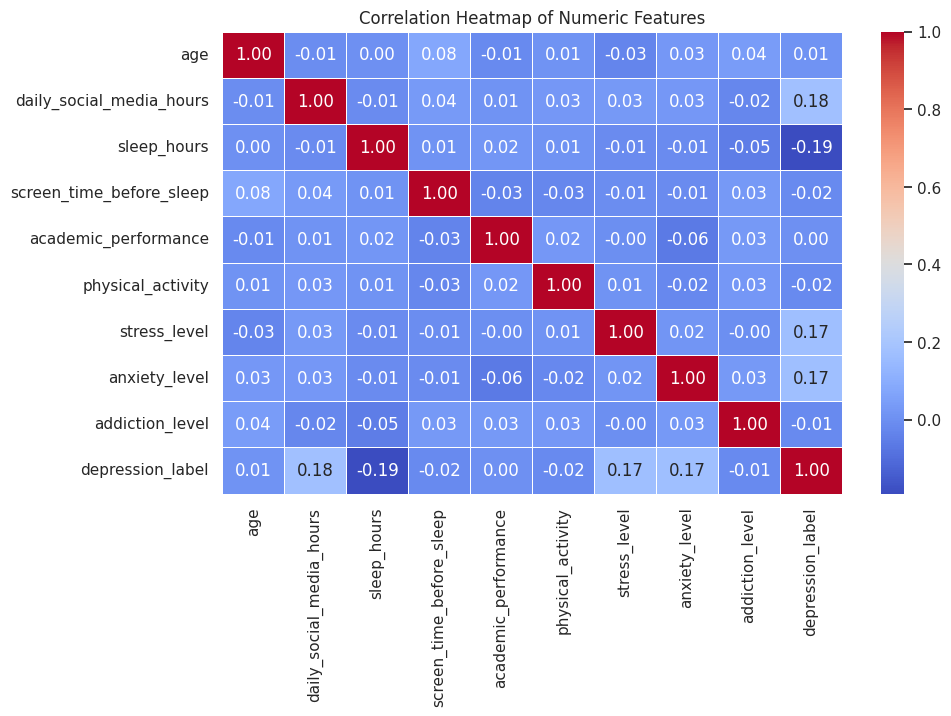

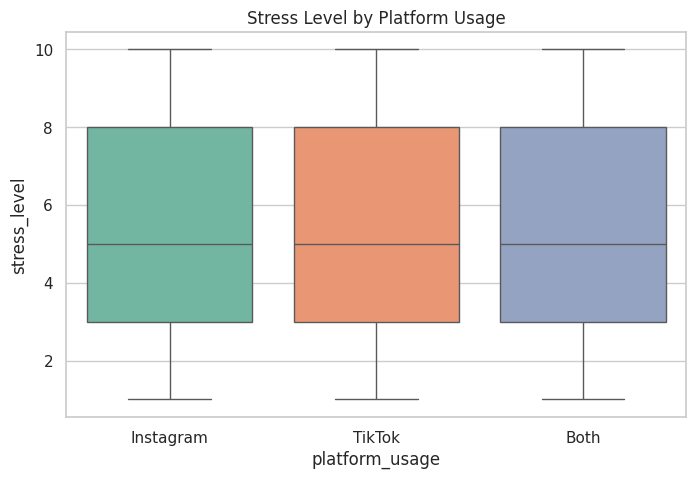

In [3]:
# 1. Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['daily_social_media_hours'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Daily Social Media Hours')

sns.histplot(df['sleep_hours'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Sleep Hours')
plt.tight_layout()
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(10, 6))
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_cols.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

# 3. Categorical Relationship (Stress by Platform)
plt.figure(figsize=(8, 5))
sns.boxplot(x='platform_usage', y='stress_level', data=df, hue='platform_usage', palette='Set2')
plt.title('Stress Level by Platform Usage')
plt.show()

## 4. Structured Data Querying with SQL
We will load the cleaned Pandas DataFrame into an in-memory SQLite database to perform structured SQL queries.

In [4]:
import sqlite3

# Create an in-memory SQLite database and load the DataFrame
conn = sqlite3.connect(':memory:')
df.to_sql('teen_mental_health', conn, index=False, if_exists='replace')

# Query: Find average stress and anxiety levels grouped by platform usage
query = """
SELECT
    platform_usage,
    COUNT(*) as user_count,
    ROUND(AVG(stress_level), 2) as avg_stress,
    ROUND(AVG(anxiety_level), 2) as avg_anxiety
FROM
    teen_mental_health
GROUP BY
    platform_usage
ORDER BY
    avg_stress DESC;
"""

# Execute query and display results
sql_results = pd.read_sql_query(query, conn)
print('SQL Query Results: Average Mental Health Metrics by Platform')
display(sql_results)

SQL Query Results: Average Mental Health Metrics by Platform


,platform_usage,user_count,avg_stress,avg_anxiety
0,Both,391,5.55,5.49
1,Instagram,411,5.50,5.67
2,TikTok,398,5.29,5.75


---
# Part 2: Predicting Stress Level
We use machine learning to predict a teen's `stress_level` from all available features (demographics, lifestyle habits, and other mental health indicators).

## 5. Data Preparation for Machine Learning
Machine learning models require numerical input. We need to convert our categorical variables (`gender`, `platform_usage`, `social_interaction_level`) into numeric format using one-hot encoding. We will predict `stress_level`.

In [5]:
from sklearn.model_selection import train_test_split

# Prepare features (X) and target (y)
X_raw = df.drop(columns=['stress_level'])
y = df['stress_level']

# One-hot encode categorical variables
X = pd.get_dummies(X_raw, drop_first=True)

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training data shape: {X_train.shape}')
print(f'Testing data shape: {X_test.shape}')
display(X.head())

Training data shape: (960, 14)
Testing data shape: (240, 14)


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,anxiety_level,addiction_level,depression_label,gender_male,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_low,social_interaction_level_medium
0,14,7.9,7.4,2.9,3.01,1.5,2,1,0,True,True,False,True,False
1,19,1.9,8.0,2.9,3.22,0.8,1,10,0,False,False,True,False,False
2,17,1.3,7.6,0.5,3.92,0.0,4,2,0,False,True,False,False,False
3,15,7.4,6.9,1.6,3.48,0.8,7,9,0,True,False,True,False,True
4,15,4.7,4.9,3.0,2.37,1.4,5,2,0,False,False,False,False,True


## 6. Model Training and Evaluation
We will use a **Random Forest Regressor** to predict stress levels. After training, we will evaluate its performance using Mean Squared Error (MSE) and R-squared ($R^2$).

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('--- Model Evaluation ---')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'R-squared (R2 Score): {r2:.2f}')

--- Model Evaluation ---
Mean Squared Error (MSE): 8.25
R-squared (R2 Score): -0.06


## 7. Feature Importance
Let's visualize which features were most important in predicting a teen's stress level according to our Random Forest model.

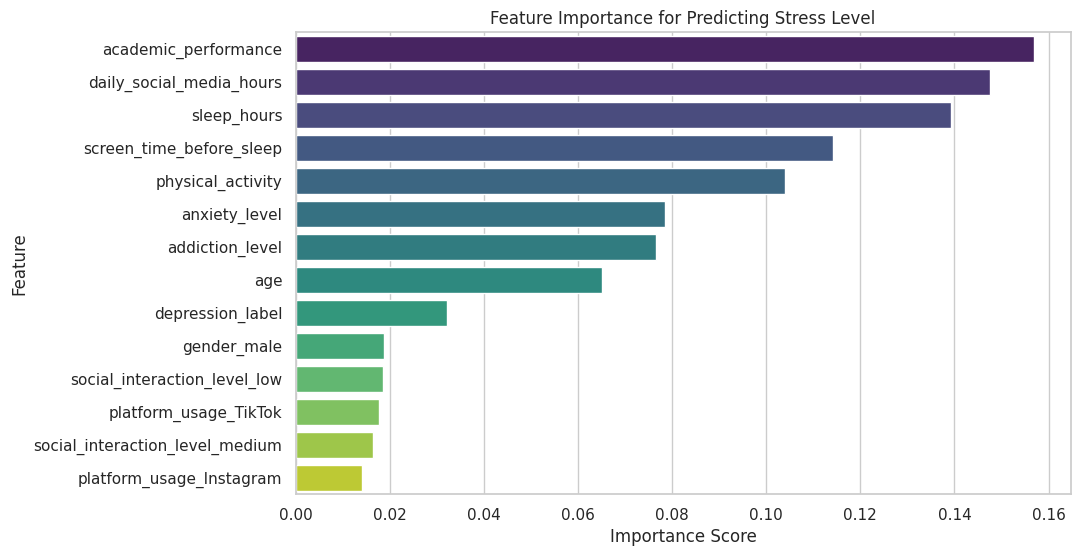

In [7]:
# Extract feature importances
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance for Predicting Stress Level')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

## 8. Hyperparameter Tuning
To improve our model's performance and increase the $R^2$ score, we use `GridSearchCV` to find the optimal hyperparameters for our Random Forest model.

In [8]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize and run Grid Search
rf_base = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=1, scoring='r2')

print('Searching for the best hyperparameters...')
grid_search.fit(X_train, y_train)

# Get the best parameters and model
best_params = grid_search.best_params_
print(f'\nBest parameters found: {best_params}')

best_rf_model = grid_search.best_estimator_

# Evaluate the tuned model
y_pred_tuned = best_rf_model.predict(X_test)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print('\n--- Tuned Model Evaluation ---')
print(f'Mean Squared Error (MSE): {mse_tuned:.2f}')
print(f'R-squared (R2 Score): {r2_tuned:.2f}')

Searching for the best hyperparameters...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters found: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}

--- Tuned Model Evaluation ---
Mean Squared Error (MSE): 8.27
R-squared (R2 Score): -0.07


## 9. Making Predictions for a New User
Now that our model is trained, we can use it to predict the stress level of a hypothetical person. You can change the values in the `new_person` dictionary below to see how different habits impact the predicted stress level.

In [9]:
# Define a new person's habits (try changing these!)
new_person = {
    'age': 16,
    'gender': 'female',
    'daily_social_media_hours': 6.5,
    'platform_usage': 'TikTok',
    'sleep_hours': 5.0,
    'screen_time_before_sleep': 2.5,
    'academic_performance': 2.8,
    'physical_activity': 0.5,
    'social_interaction_level': 'low',
    'anxiety_level': 8,
    'addiction_level': 7,
    'depression_label': 1
}

# Convert to DataFrame and preprocess
new_df = pd.DataFrame([new_person])
new_X = pd.get_dummies(new_df)
new_X = new_X.reindex(columns=X.columns, fill_value=0)

# Predict
predicted_stress = rf_model.predict(new_X)
print(f'Based on the inputted habits, the predicted Stress Level is: {predicted_stress[0]:.2f} (out of 10)')

Based on the inputted habits, the predicted Stress Level is: 8.31 (out of 10)


## 10. Interactive Model Comparison
Below is an interactive widget to tweak a user's habits and immediately compare the **Base Model** and **Tuned Model** predictions. Following that, we plot a comparison map to visualize how the tuning shifted predictions on the test dataset.

In [10]:
import ipywidgets as widgets
from IPython.display import display

stress_gender_options = ['female', 'male', 'non-binary']
stress_platform_options = ['Both', 'Instagram', 'Other', 'TikTok']
stress_interaction_options = ['high', 'low', 'medium']


def compare_models(
    age,
    social_hours,
    sleep,
    screen_time,
    academic,
    physical,
    anxiety,
    addiction,
    depression,
    gender,
    platform,
    interaction,
):
    new_person = {
        'age': age,
        'gender': gender,
        'daily_social_media_hours': social_hours,
        'platform_usage': platform,
        'sleep_hours': sleep,
        'screen_time_before_sleep': screen_time,
        'academic_performance': academic,
        'physical_activity': physical,
        'social_interaction_level': interaction,
        'anxiety_level': anxiety,
        'addiction_level': addiction,
        'depression_label': depression,
    }

    new_df = pd.DataFrame([new_person])
    new_X = pd.get_dummies(new_df).reindex(columns=X.columns, fill_value=0)

    pred_base = rf_model.predict(new_X)[0]
    pred_tuned = best_rf_model.predict(new_X)[0]

    print('--- Prediction Comparison ---')
    print(f'Base Model Predicted Stress:  {pred_base:.2f}')
    print(f'Tuned Model Predicted Stress: {pred_tuned:.2f}')
    print(f'Difference (Tuned - Base):    {pred_tuned - pred_base:.2f}')


stress_controls = {
    'age': widgets.IntSlider(min=10, max=25, step=1, value=16, description='Age'),
    'social_hours': widgets.FloatSlider(
        min=0.0,
        max=15.0,
        step=0.5,
        value=5.0,
        description='Social Media (hrs)',
        style={'description_width': 'initial'},
    ),
    'sleep': widgets.FloatSlider(min=0.0, max=15.0, step=0.5, value=7.0, description='Sleep (hrs)'),
    'screen_time': widgets.FloatSlider(
        min=0.0,
        max=10.0,
        step=0.5,
        value=2.0,
        description='Pre-Sleep Screen (hrs)',
        style={'description_width': 'initial'},
    ),
    'academic': widgets.FloatSlider(min=0.0, max=4.0, step=0.1, value=3.0, description='Academic Perf'),
    'physical': widgets.FloatSlider(
        min=0.0,
        max=5.0,
        step=0.1,
        value=1.0,
        description='Physical Activity',
        style={'description_width': 'initial'},
    ),
    'anxiety': widgets.IntSlider(min=1, max=10, step=1, value=5, description='Anxiety'),
    'addiction': widgets.IntSlider(min=1, max=10, step=1, value=5, description='Addiction'),
    'depression': widgets.IntSlider(min=0, max=1, step=1, value=0, description='Depression'),
    'gender': widgets.Dropdown(options=stress_gender_options, value='female', description='Gender'),
    'platform': widgets.Dropdown(options=stress_platform_options, value='TikTok', description='Platform'),
    'interaction': widgets.Dropdown(
        options=stress_interaction_options,
        value='medium',
        description='Social Interaction',
        style={'description_width': 'initial'},
    ),
}

stress_ui = widgets.VBox(list(stress_controls.values()))
stress_output = widgets.interactive_output(compare_models, stress_controls)
display(stress_ui, stress_output)

Output()

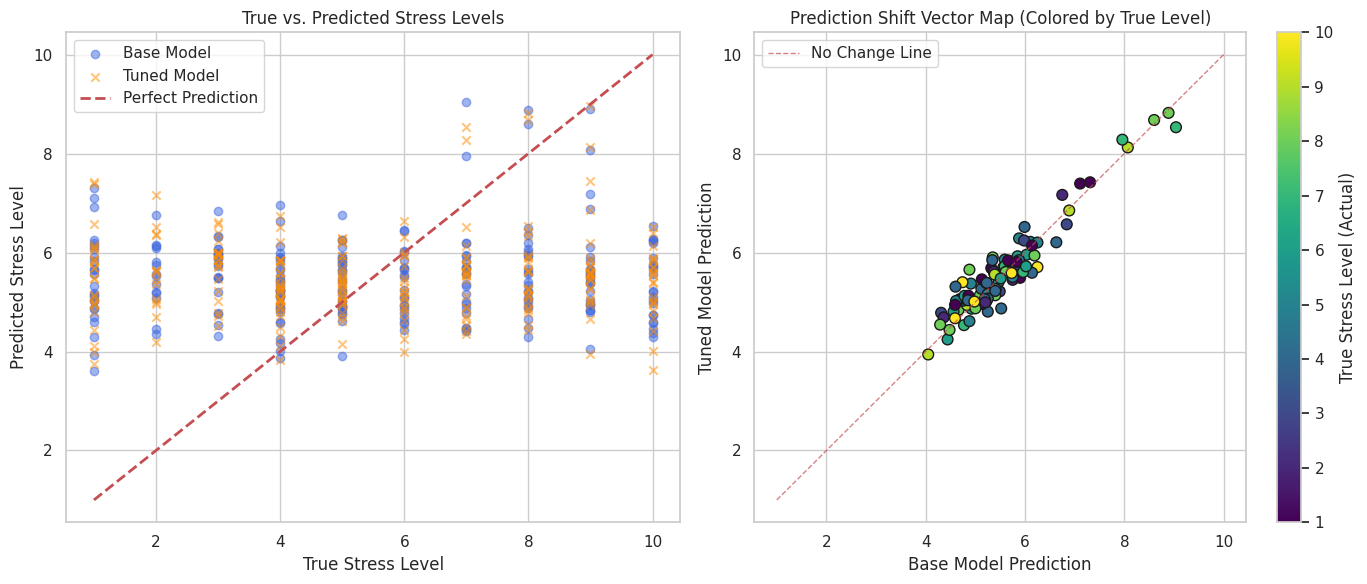

In [11]:
plt.figure(figsize=(14, 6))

# 1. Scatter Plot: True vs Predicted for both models
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, label='Base Model', color='royalblue', marker='o')
plt.scatter(y_test, y_pred_tuned, alpha=0.5, label='Tuned Model', color='darkorange', marker='x')
min_val = min(y_test.min(), y_pred.min(), y_pred_tuned.min())
max_val = max(y_test.max(), y_pred.max(), y_pred_tuned.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('True Stress Level')
plt.ylabel('Predicted Stress Level')
plt.title('True vs. Predicted Stress Levels')
plt.legend()

# 2. Vector Map (Base vs Tuned Predictions)
plt.subplot(1, 2, 2)
subset = 100
sc = plt.scatter(y_pred[:subset], y_pred_tuned[:subset], c=y_test[:subset], cmap='viridis', s=60, edgecolor='k')
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1, alpha=0.7, label='No Change Line')
plt.xlabel('Base Model Prediction')
plt.ylabel('Tuned Model Prediction')
plt.title('Prediction Shift Vector Map (Colored by True Level)')
plt.colorbar(sc, label='True Stress Level (Actual)')
plt.legend()

plt.tight_layout()
plt.show()

---
# Part 3: Composite Unhealthy Score Analysis
Instead of just predicting stress, we create a composite `unhealthy_score` combining `stress_level`, `anxiety_level`, `addiction_level`, and `depression_label`. We then use **only lifestyle features** (screen time, sleep, physical activity, etc.) to predict this score and identify the most damaging habits.

## 11. Creating the Composite Unhealthy Score
We weight depression slightly higher (×5) since it's a binary 0/1 label, while the other components are on 1–10 scales.

In [12]:
# Create a composite 'unhealthy_score'
df['unhealthy_score'] = (df['stress_level'] + df['anxiety_level'] +
                         df['addiction_level'] + (df['depression_label'] * 5))

# Select only lifestyle and demographic features (excluding mental health outcomes)
lifestyle_features = [
    'age', 'gender', 'daily_social_media_hours', 'platform_usage',
    'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
    'physical_activity', 'social_interaction_level'
]

X_habits_raw = df[lifestyle_features]
y_unhealthy = df['unhealthy_score']

# One-hot encode categorical features
X_habits = pd.get_dummies(X_habits_raw, drop_first=True)

# Split the data
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_habits, y_unhealthy, test_size=0.2, random_state=42)

# Train a Random Forest model
rf_habits = RandomForestRegressor(n_estimators=100, random_state=42)
rf_habits.fit(X_train_h, y_train_h)

print(f'Model trained to predict Unhealthy Score using {len(X_habits.columns)} lifestyle features.')

Model trained to predict Unhealthy Score using 11 lifestyle features.


## 12. Feature Importances — Which Habits Drive Poor Mental Health?
Let's visualize which lifestyle factors are most important in predicting the composite unhealthy score.

/tmp/ipykernel_45702/3127569435.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Habit_Feature', data=habit_importance_df, palette='Reds_r')


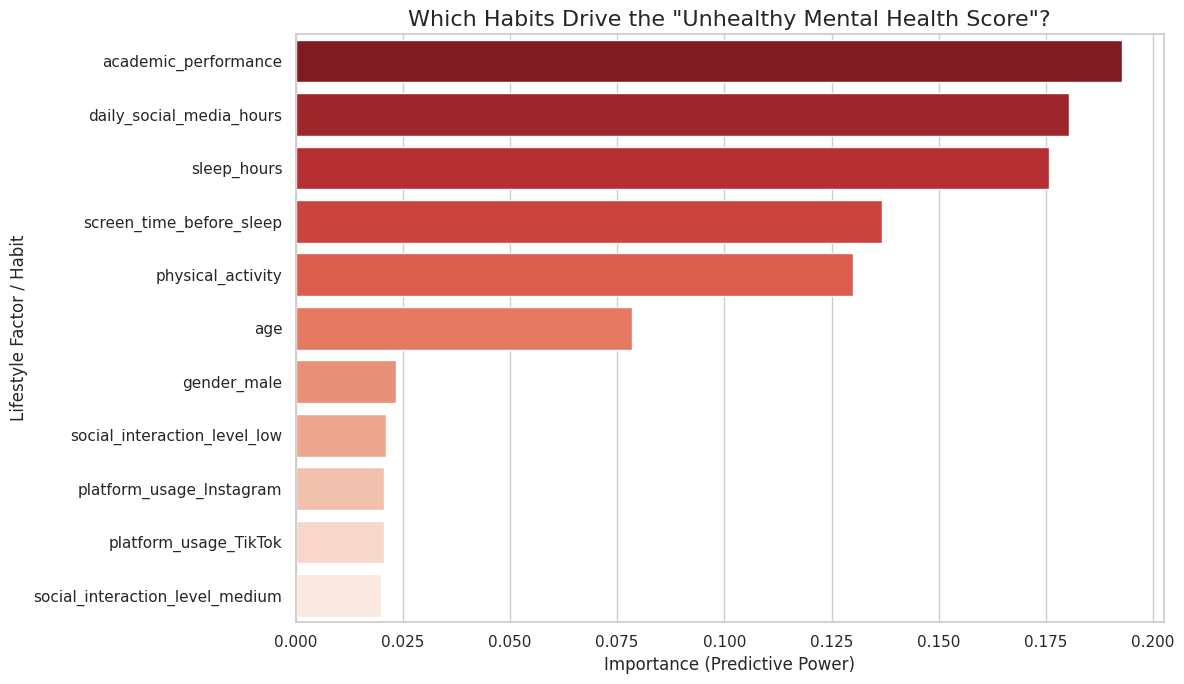

In [13]:
importances_h = rf_habits.feature_importances_

habit_importance_df = pd.DataFrame({
    'Habit_Feature': X_habits.columns,
    'Importance': importances_h
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Habit_Feature', data=habit_importance_df, palette='Reds_r')
plt.title('Which Habits Drive the "Unhealthy Mental Health Score"?', fontsize=16)
plt.xlabel('Importance (Predictive Power)', fontsize=12)
plt.ylabel('Lifestyle Factor / Habit', fontsize=12)
plt.tight_layout()
plt.show()

## 13. Unhealthy Score Model Evaluation
Let's evaluate the performance of the Random Forest model and visualize actual vs. predicted values.

--- 'Unhealthy Mental Health Score' Model Evaluation ---
Mean Squared Error (MSE): 30.51
R-squared (R2 Score): -0.10


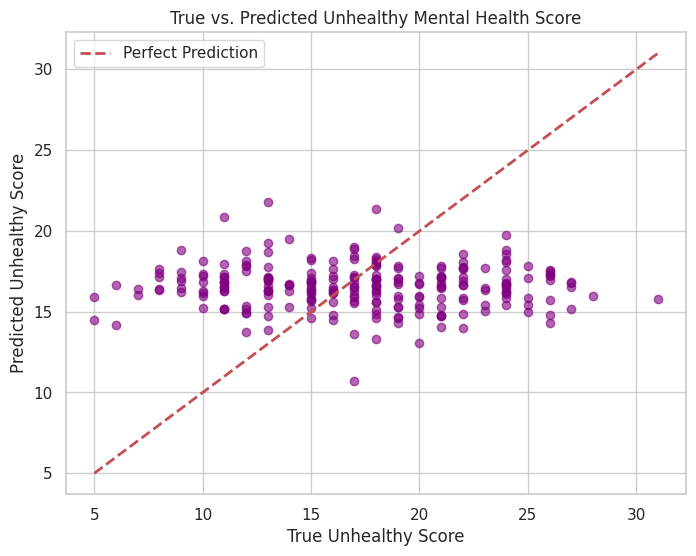

In [14]:
# Predict on the test set
y_pred_unhealthy = rf_habits.predict(X_test_h)

# Evaluate
mse_unhealthy = mean_squared_error(y_test_h, y_pred_unhealthy)
r2_unhealthy = r2_score(y_test_h, y_pred_unhealthy)

print("--- 'Unhealthy Mental Health Score' Model Evaluation ---")
print(f'Mean Squared Error (MSE): {mse_unhealthy:.2f}')
print(f'R-squared (R2 Score): {r2_unhealthy:.2f}')

# Actual vs Predicted scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test_h, y_pred_unhealthy, alpha=0.6, color='purple')
plt.plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('True Unhealthy Score')
plt.ylabel('Predicted Unhealthy Score')
plt.title('True vs. Predicted Unhealthy Mental Health Score')
plt.legend()
plt.grid(True)
plt.show()

## 14. Comparing Feature Importances: Stress Level vs. Unhealthy Score
Let's compare the top features from both models. This highlights which factors are universally important for mental health and which are specific to each target.

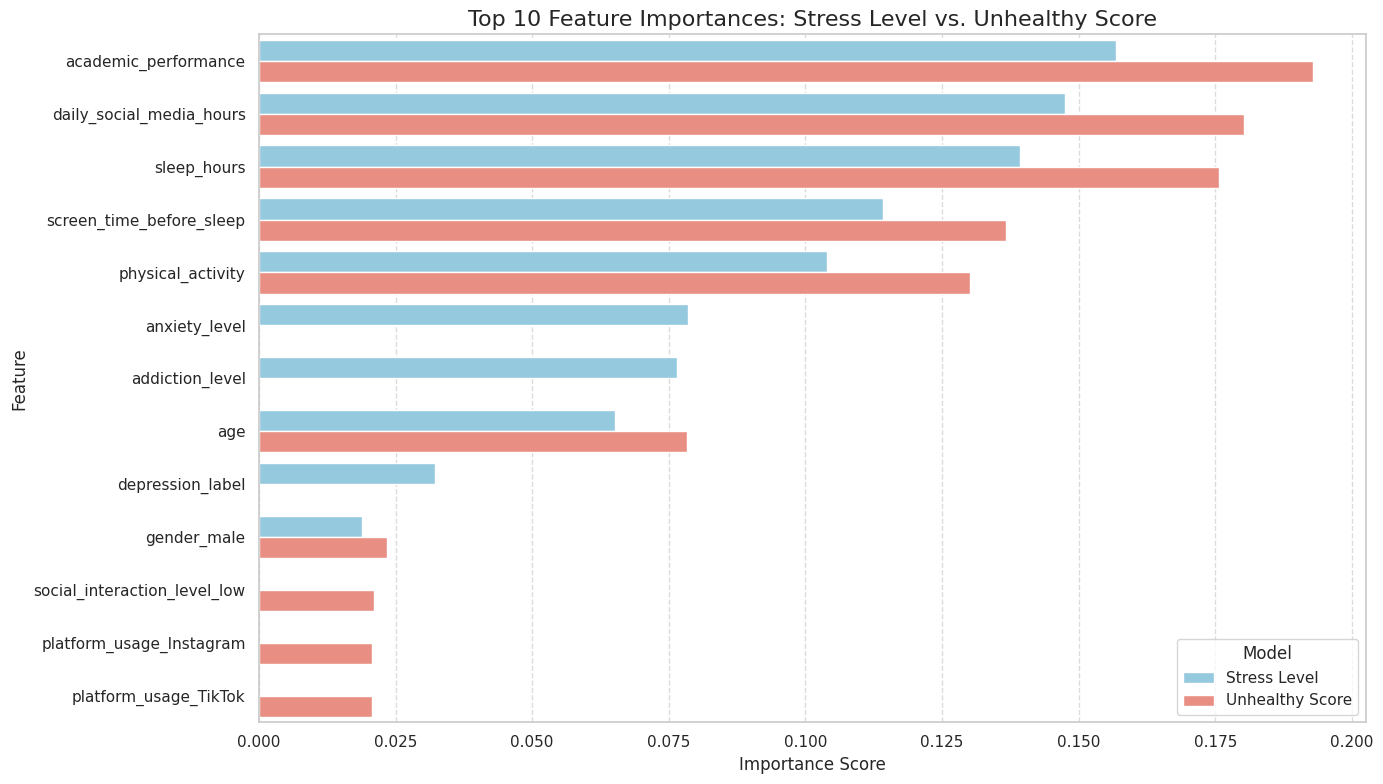

In [15]:
# Feature importances for stress_level model
importance_df_stress = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})
importance_df_stress['Model'] = 'Stress Level'

# Feature importances for unhealthy_score model
importance_df_unhealthy = pd.DataFrame({
    'Feature': X_habits.columns,
    'Importance': rf_habits.feature_importances_
})
importance_df_unhealthy['Model'] = 'Unhealthy Score'

# Get top 10 from each and combine
top_n = 10
top_stress = importance_df_stress.sort_values('Importance', ascending=False).head(top_n)
top_unhealthy = importance_df_unhealthy.sort_values('Importance', ascending=False).head(top_n)
plot_df = pd.concat([top_stress, top_unhealthy])

plt.figure(figsize=(14, 8))
sns.barplot(x='Importance', y='Feature', hue='Model', data=plot_df.sort_values(
    by=['Model', 'Importance'], ascending=[True, False]),
    palette={'Stress Level': 'skyblue', 'Unhealthy Score': 'salmon'})
plt.title(f'Top {top_n} Feature Importances: Stress Level vs. Unhealthy Score', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 15. Improving the Unhealthy Score Model (Hyperparameter Tuning)
The base model for the `unhealthy_score` had poor predictive performance. Let's use `GridSearchCV` to find optimal hyperparameters.

In [16]:
# Define the parameter grid
param_grid_h = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize and run Grid Search
rf_base_h = RandomForestRegressor(random_state=42)
grid_search_h = GridSearchCV(estimator=rf_base_h, param_grid=param_grid_h,
                             cv=5, n_jobs=-1, verbose=1, scoring='r2')

print('Searching for the best hyperparameters for the Unhealthy Score Model...')
grid_search_h.fit(X_train_h, y_train_h)

# Best model
best_rf_habits = grid_search_h.best_estimator_
print(f'\nBest parameters found: {grid_search_h.best_params_}')

# Evaluate
y_pred_tuned_h = best_rf_habits.predict(X_test_h)
mse_tuned_h = mean_squared_error(y_test_h, y_pred_tuned_h)
r2_tuned_h = r2_score(y_test_h, y_pred_tuned_h)

print("\n--- Tuned 'Unhealthy Score' Model Evaluation ---")
print(f'Mean Squared Error (MSE): {mse_tuned_h:.2f}')
print(f'R-squared (R2 Score): {r2_tuned_h:.2f}')

Searching for the best hyperparameters for the Unhealthy Score Model...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best parameters found: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}

--- Tuned 'Unhealthy Score' Model Evaluation ---
Mean Squared Error (MSE): 29.64
R-squared (R2 Score): -0.07


## 16. Comparing Alternative Models
Since the Random Forest model struggled to achieve a positive $R^2$ score, let's test Linear Regression, Gradient Boosting, and XGBoost to see if they can better capture the relationship.

In [17]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

alternative_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, objective='reg:squarederror')
}

model_results = []

print("Evaluating alternative models for 'unhealthy_score'...\n")
for name, model in alternative_models.items():
    model.fit(X_train_h, y_train_h)
    y_pred_alt = model.predict(X_test_h)
    mse_alt = mean_squared_error(y_test_h, y_pred_alt)
    r2_alt = r2_score(y_test_h, y_pred_alt)
    model_results.append({'Model': name, 'MSE': round(mse_alt, 2), 'R2 Score': round(r2_alt, 4)})

results_df = pd.DataFrame(model_results)
display(results_df.sort_values(by='R2 Score', ascending=False))

print(f'\n(Reference) Tuned Random Forest — MSE: {mse_tuned_h:.2f} | R2: {r2_tuned_h:.4f}')

Evaluating alternative models for 'unhealthy_score'...



,Model,MSE,R2 Score
1,Ridge Regression,28.04,-0.0081
0,Linear Regression,28.04,-0.0082
2,Gradient Boosting,30.80,-0.1074
3,XGBoost,37.58,-0.3509



(Reference) Tuned Random Forest — MSE: 29.64 | R2: -0.0654


## 17. Interactive Unhealthy Score Prediction
Adjust the lifestyle habits below to see how the tuned model predicts a teen's composite unhealthy score.

In [18]:
import ipywidgets as widgets
from IPython.display import display

habit_gender_options = ['female', 'male', 'non-binary']
habit_platform_options = ['Both', 'Instagram', 'Other', 'TikTok']
habit_interaction_options = ['high', 'low', 'medium']


def predict_unhealthy_score(age, social_hours, sleep, screen_time, academic, physical, gender, platform, interaction):
    new_data = {
        'age': [age],
        'daily_social_media_hours': [social_hours],
        'sleep_hours': [sleep],
        'screen_time_before_sleep': [screen_time],
        'academic_performance': [academic],
        'physical_activity': [physical],
        'gender': [gender],
        'platform_usage': [platform],
        'social_interaction_level': [interaction],
    }
    new_df = pd.DataFrame(new_data)
    new_X = pd.get_dummies(new_df).reindex(columns=X_habits.columns, fill_value=0)

    pred_score = best_rf_habits.predict(new_X)[0]
    print('=' * 40)
    print(f'Predicted Unhealthy Score: {pred_score:.2f} (Scale: ~0 to 35)')
    print('=' * 40)
    print('Higher scores indicate greater predicted stress, anxiety, addiction, and depression risk.')


habit_controls = {
    'age': widgets.IntSlider(min=10, max=25, step=1, value=16, description='Age'),
    'social_hours': widgets.FloatSlider(
        min=0.0,
        max=15.0,
        step=0.5,
        value=5.0,
        description='Social Media (hrs)',
        style={'description_width': 'initial'},
    ),
    'sleep': widgets.FloatSlider(min=0.0, max=15.0, step=0.5, value=7.0, description='Sleep (hrs)'),
    'screen_time': widgets.FloatSlider(
        min=0.0,
        max=10.0,
        step=0.5,
        value=2.0,
        description='Pre-Sleep Screen (hrs)',
        style={'description_width': 'initial'},
    ),
    'academic': widgets.FloatSlider(min=0.0, max=4.0, step=0.1, value=3.0, description='Academic Perf'),
    'physical': widgets.FloatSlider(
        min=0.0,
        max=5.0,
        step=0.1,
        value=1.0,
        description='Physical Activity',
        style={'description_width': 'initial'},
    ),
    'gender': widgets.Dropdown(options=habit_gender_options, value='female', description='Gender'),
    'platform': widgets.Dropdown(options=habit_platform_options, value='TikTok', description='Platform'),
    'interaction': widgets.Dropdown(
        options=habit_interaction_options,
        value='medium',
        description='Social Interaction',
        style={'description_width': 'initial'},
    ),
}

habit_ui = widgets.VBox(list(habit_controls.values()))
habit_output = widgets.interactive_output(predict_unhealthy_score, habit_controls)
display(habit_ui, habit_output)

Output()

## 18. Why We Shifted from Regression to Classification

Up to this point, the project tried two regression-style prediction tasks:

1. Predicting `stress_level` using the rest of the dataset, including other mental-health variables.
2. Predicting a lifestyle-only composite `unhealthy_score` built from stress, anxiety, addiction, and depression.

Those trials were still useful, but neither produced a strong predictive model.

**What did not work well:**
- The **stress level model** produced weak performance, even when other mental-health indicators were included.
- The **composite unhealthy score model** also performed poorly when restricted to lifestyle factors, with a negative $R^2$ in the earlier evaluation.
- This suggests that the continuous outcomes in this dataset are either too noisy, too simplified, or influenced by important missing variables that were not measured.

**Why this matters:**
- A weak regression result does not necessarily mean the dataset contains no signal.
- It may mean that predicting an exact continuous score is the wrong framing.
- A more realistic question is whether lifestyle patterns can help identify teens who fall into a **higher-risk category**, even if they cannot precisely predict a score.

That motivates the next section, where the project reframes the task as a classification problem instead of a regression problem.

## 19. High-Risk Teen Classification from Lifestyle Factors

Since the regression model for the composite `unhealthy_score` was weak, we now reframe the problem as **binary classification**: can lifestyle factors help us identify teens who fall into a high-risk mental-health group?

Because different definitions of "high risk" can lead to very different results, we test several candidate targets and compare multiple classification models. Since some outcomes are highly imbalanced, we focus on **ROC-AUC** and **average precision** in addition to accuracy and F1-score.

In [19]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, average_precision_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

# Reload a clean copy so this section can run independently from earlier cells
risk_df = pd.read_csv('Teen_Mental_Health_Dataset.csv')
risk_df['unhealthy_score'] = (
    risk_df['stress_level'] + risk_df['anxiety_level'] +
    risk_df['addiction_level'] + (risk_df['depression_label'] * 5)
)

risk_features = [
    'age', 'gender', 'daily_social_media_hours', 'platform_usage',
    'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
    'physical_activity', 'social_interaction_level'
]

X_risk = pd.get_dummies(risk_df[risk_features], drop_first=False)

candidate_targets = {
    'depression_label': risk_df['depression_label'].astype(int),
    'top_25pct_unhealthy_score': (risk_df['unhealthy_score'] >= risk_df['unhealthy_score'].quantile(0.75)).astype(int),
    'depression_or_high_anxiety': ((risk_df['depression_label'] == 1) | (risk_df['anxiety_level'] >= 8)).astype(int)
}

candidate_models = {
    'Logistic Regression (balanced)': LogisticRegression(max_iter=3000, class_weight='balanced'),
    'Random Forest (balanced)': RandomForestClassifier(n_estimators=400, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

comparison_rows = []
for target_name, y_target in candidate_targets.items():
    X_train_cmp, X_test_cmp, y_train_cmp, y_test_cmp = train_test_split(
        X_risk, y_target, test_size=0.2, random_state=42, stratify=y_target
    )

    for model_name, model in candidate_models.items():
        model.fit(X_train_cmp, y_train_cmp)
        y_pred_cmp = model.predict(X_test_cmp)
        y_prob_cmp = model.predict_proba(X_test_cmp)[:, 1]

        comparison_rows.append({
            'target': target_name,
            'model': model_name,
            'positive_rate': y_target.mean(),
            'accuracy': accuracy_score(y_test_cmp, y_pred_cmp),
            'f1_score': f1_score(y_test_cmp, y_pred_cmp, zero_division=0),
            'roc_auc': roc_auc_score(y_test_cmp, y_prob_cmp),
            'avg_precision': average_precision_score(y_test_cmp, y_prob_cmp)
        })

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    by=['roc_auc', 'avg_precision', 'f1_score'], ascending=False
)

print('--- High-Risk Classification Model Comparison ---')
display(comparison_df.round({
    'positive_rate': 3,
    'accuracy': 3,
    'f1_score': 3,
    'roc_auc': 3,
    'avg_precision': 3
}))

best_row = comparison_df.iloc[0]
print(
    f"\nBest ranking result: {best_row['model']} on '{best_row['target']}' "
    f"with ROC-AUC = {best_row['roc_auc']:.3f} and Average Precision = {best_row['avg_precision']:.3f}."
)

--- High-Risk Classification Model Comparison ---


,target,model,positive_rate,accuracy,f1_score,roc_auc,avg_precision
2,depression_label,Gradient Boosting,0.026,0.971,0.000,0.920,0.149
0,depression_label,Logistic Regression (balanced),0.026,0.875,0.211,0.918,0.174
1,depression_label,Random Forest (balanced),0.026,0.975,0.000,0.911,0.154
7,depression_or_high_anxiety,Random Forest (balanced),0.326,0.650,0.045,0.557,0.363
6,depression_or_high_anxiety,Logistic Regression (balanced),0.326,0.521,0.410,0.537,0.366
8,depression_or_high_anxiety,Gradient Boosting,0.326,0.633,0.120,0.536,0.376
4,top_25pct_unhealthy_score,Random Forest (balanced),0.297,0.708,0.079,0.505,0.319
3,top_25pct_unhealthy_score,Logistic Regression (balanced),0.297,0.496,0.346,0.492,0.281
5,top_25pct_unhealthy_score,Gradient Boosting,0.297,0.704,0.145,0.459,0.321



Best ranking result: Gradient Boosting on 'depression_label' with ROC-AUC = 0.920 and Average Precision = 0.149.


--- Final High-Risk Classifier: Logistic Regression (balanced) -> hybrid_unhealthy_or_depression_or_anxiety ---
Hybrid target = top 25% unhealthy score OR depression label = 1 OR anxiety level >= 8
Positive-class rate: 0.437
Chosen threshold from training data: 0.373

Training metrics
ROC-AUC: 0.557
Average Precision: 0.490
F1-Score: 0.608

Test metrics
Test Accuracy: 0.433
Test ROC-AUC: 0.502
Test Average Precision: 0.459
Test F1-Score: 0.605
Test Precision: 0.435
Test Recall: 0.990
5-fold CV ROC-AUC (mean): 0.491
5-fold CV Avg Precision (mean): 0.438

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       135
           1       0.44      0.99      0.60       105

    accuracy                           0.43       240
   macro avg       0.22      0.50      0.30       240
weighted avg       0.19      0.43      0.26       240



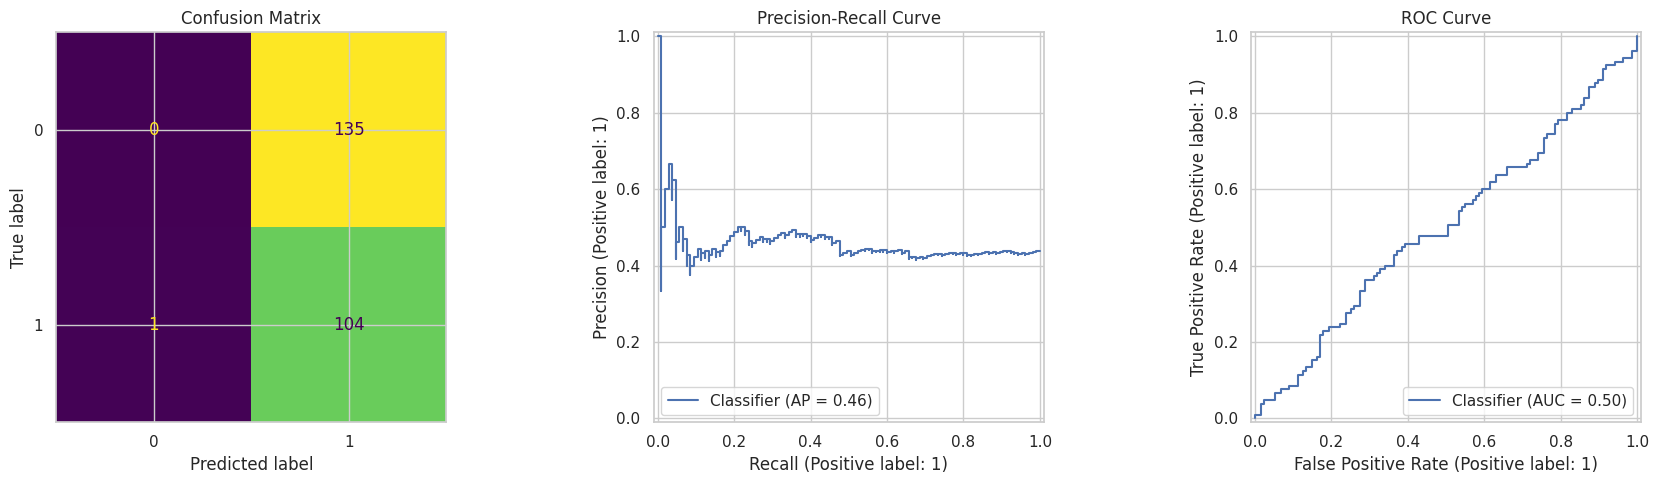

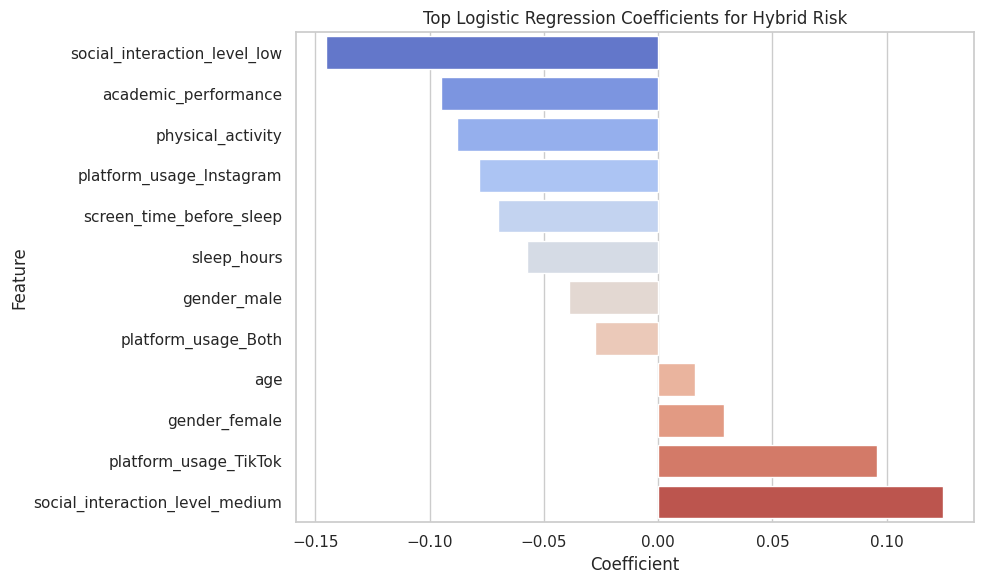

,feature,coefficient
12,social_interaction_level_low,-0.145121
13,social_interaction_level_medium,0.124677
10,platform_usage_TikTok,0.095769
4,academic_performance,-0.095092
5,physical_activity,-0.087910
9,platform_usage_Instagram,-0.078202
3,screen_time_before_sleep,-0.069858
2,sleep_hours,-0.057402
7,gender_male,-0.039098
6,gender_female,0.028984


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

# Build a broader, more stable screening target instead of modeling depression_label alone.
risk_df_final = pd.read_csv('Teen_Mental_Health_Dataset.csv')
risk_df_final['unhealthy_score'] = (
    risk_df_final['stress_level'] + risk_df_final['anxiety_level'] +
    risk_df_final['addiction_level'] + (risk_df_final['depression_label'] * 5)
)

risk_features_final = [
    'age', 'gender', 'daily_social_media_hours', 'platform_usage',
    'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
    'physical_activity', 'social_interaction_level'
]
X_final = pd.get_dummies(risk_df_final[risk_features_final], drop_first=False)

best_target_name = 'hybrid_unhealthy_or_depression_or_anxiety'
y_final = (
    (risk_df_final['unhealthy_score'] >= risk_df_final['unhealthy_score'].quantile(0.75))
    | (risk_df_final['depression_label'] == 1)
    | (risk_df_final['anxiety_level'] >= 8)
).astype(int)

best_model_name = 'Logistic Regression (balanced)'
high_risk_model = LogisticRegression(max_iter=3000, class_weight='balanced')

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

high_risk_model.fit(X_train_final, y_train_final)

train_prob = high_risk_model.predict_proba(X_train_final)[:, 1]
test_prob = high_risk_model.predict_proba(X_test_final)[:, 1]

precision_vals, recall_vals, thresholds = precision_recall_curve(y_train_final, train_prob)
f1_vals = 2 * precision_vals[:-1] * recall_vals[:-1] / np.clip(precision_vals[:-1] + recall_vals[:-1], 1e-12, None)
best_idx = np.nanargmax(f1_vals)
best_threshold = thresholds[best_idx]

y_pred_train = (train_prob >= best_threshold).astype(int)
y_pred_final = (test_prob >= best_threshold).astype(int)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_roc_auc = cross_val_score(
    clone(high_risk_model),
    X_final,
    y_final,
    cv=cv,
    scoring='roc_auc'
)
cv_avg_precision = cross_val_score(
    clone(high_risk_model),
    X_final,
    y_final,
    cv=cv,
    scoring='average_precision'
)

print(f'--- Final High-Risk Classifier: {best_model_name} -> {best_target_name} ---')
print('Hybrid target = top 25% unhealthy score OR depression label = 1 OR anxiety level >= 8')
print(f'Positive-class rate: {y_final.mean():.3f}')
print(f'Chosen threshold from training data: {best_threshold:.3f}')
print()
print('Training metrics')
print(f"ROC-AUC: {roc_auc_score(y_train_final, train_prob):.3f}")
print(f"Average Precision: {average_precision_score(y_train_final, train_prob):.3f}")
print(f"F1-Score: {f1_score(y_train_final, y_pred_train, zero_division=0):.3f}")
print()
print('Test metrics')
print(f'Test Accuracy: {accuracy_score(y_test_final, y_pred_final):.3f}')
print(f'Test ROC-AUC: {roc_auc_score(y_test_final, test_prob):.3f}')
print(f'Test Average Precision: {average_precision_score(y_test_final, test_prob):.3f}')
print(f'Test F1-Score: {f1_score(y_test_final, y_pred_final, zero_division=0):.3f}')
print(f'Test Precision: {precision_score(y_test_final, y_pred_final, zero_division=0):.3f}')
print(f'Test Recall: {recall_score(y_test_final, y_pred_final, zero_division=0):.3f}')
print(f'5-fold CV ROC-AUC (mean): {cv_roc_auc.mean():.3f}')
print(f'5-fold CV Avg Precision (mean): {cv_avg_precision.mean():.3f}')
print('\nClassification Report:')
print(classification_report(y_test_final, y_pred_final, zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test_final, y_pred_final)).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')
PrecisionRecallDisplay.from_predictions(y_test_final, test_prob, ax=axes[1])
axes[1].set_title('Precision-Recall Curve')
RocCurveDisplay.from_predictions(y_test_final, test_prob, ax=axes[2])
axes[2].set_title('ROC Curve')
plt.tight_layout()
plt.show()

coef_df = pd.DataFrame({
    'feature': X_final.columns,
    'coefficient': high_risk_model.coef_[0],
    'abs_coefficient': np.abs(high_risk_model.coef_[0]),
}).sort_values('abs_coefficient', ascending=False)
feature_view = coef_df.head(12).sort_values('coefficient')
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_view, x='coefficient', y='feature', hue='feature', dodge=False, palette='coolwarm', legend=False)
plt.title('Top Logistic Regression Coefficients for Hybrid Risk')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
display(coef_df[['feature', 'coefficient']].head(12))

## 20. Interactive High-Risk Screening Test

The final classifier now uses a broader hybrid target instead of `depression_label` alone:

- `unhealthy_score` in the top 25%
- or `depression_label = 1`
- or `anxiety_level >= 8`

This makes the model a better fit for screening, because it is trying to identify a broader high-risk group rather than a very rare single label. The output below still shows both:

- the model-based probability from the hybrid logistic-regression classifier
- a monotonic lifestyle risk score based on where the input falls within the dataset distribution

The lifestyle score is still the smoother screening tool, while the classifier provides a data-driven probability for the broader hybrid target.

In [21]:
import ipywidgets as widgets
from IPython.display import display
import numpy as np

risk_gender_options = ['female', 'male', 'non-binary']
risk_platform_options = ['Both', 'Instagram', 'Other', 'TikTok']
risk_interaction_options = ['high', 'low', 'medium']

lifestyle_risk_weights = {
    'daily_social_media_hours': 0.25,
    'sleep_hours': 0.25,
    'screen_time_before_sleep': 0.20,
    'physical_activity': 0.15,
    'academic_performance': 0.10,
    'social_interaction_level': 0.05,
}
lifestyle_interaction_risk = {'low': 1.0, 'medium': 0.5, 'high': 0.0}
lifestyle_reference = {
    'daily_social_media_hours': risk_df_final['daily_social_media_hours'].dropna().to_numpy(),
    'sleep_hours': risk_df_final['sleep_hours'].dropna().to_numpy(),
    'screen_time_before_sleep': risk_df_final['screen_time_before_sleep'].dropna().to_numpy(),
    'physical_activity': risk_df_final['physical_activity'].dropna().to_numpy(),
    'academic_performance': risk_df_final['academic_performance'].dropna().to_numpy(),
}


def percentile_risk(reference_values, value, higher_is_risk=True):
    if higher_is_risk:
        return float((reference_values <= value).mean())
    return float((reference_values >= value).mean())



def calculate_lifestyle_risk_score(social_hours, sleep, screen_time, academic, physical, interaction):
    return 100 * (
        lifestyle_risk_weights['daily_social_media_hours']
        * percentile_risk(lifestyle_reference['daily_social_media_hours'], social_hours, higher_is_risk=True)
        + lifestyle_risk_weights['sleep_hours']
        * percentile_risk(lifestyle_reference['sleep_hours'], sleep, higher_is_risk=False)
        + lifestyle_risk_weights['screen_time_before_sleep']
        * percentile_risk(lifestyle_reference['screen_time_before_sleep'], screen_time, higher_is_risk=True)
        + lifestyle_risk_weights['physical_activity']
        * percentile_risk(lifestyle_reference['physical_activity'], physical, higher_is_risk=False)
        + lifestyle_risk_weights['academic_performance']
        * percentile_risk(lifestyle_reference['academic_performance'], academic, higher_is_risk=False)
        + lifestyle_risk_weights['social_interaction_level'] * lifestyle_interaction_risk[interaction]
    )


lifestyle_dataset_scores = np.array([
    calculate_lifestyle_risk_score(
        row.daily_social_media_hours,
        row.sleep_hours,
        row.screen_time_before_sleep,
        row.academic_performance,
        row.physical_activity,
        row.social_interaction_level,
    )
    for row in risk_df_final.itertuples(index=False)
])
lifestyle_moderate_risk_threshold = float(np.quantile(lifestyle_dataset_scores, 0.40))
lifestyle_high_risk_threshold = float(np.quantile(lifestyle_dataset_scores, 0.75))



def label_lifestyle_risk(score):
    if score >= lifestyle_high_risk_threshold:
        return 'High risk'
    if score >= lifestyle_moderate_risk_threshold:
        return 'Moderate risk'
    return 'Low risk'



def classify_high_risk(age, social_hours, sleep, screen_time, academic, physical, gender, platform, interaction):
    profile = pd.DataFrame([
        {
            'age': age,
            'gender': gender,
            'daily_social_media_hours': social_hours,
            'platform_usage': platform,
            'sleep_hours': sleep,
            'screen_time_before_sleep': screen_time,
            'academic_performance': academic,
            'physical_activity': physical,
            'social_interaction_level': interaction,
        }
    ])
    new_X = pd.get_dummies(profile).reindex(columns=X_final.columns, fill_value=0)

    risk_probability = high_risk_model.predict_proba(new_X)[0, 1]
    predicted_class = int(risk_probability >= best_threshold)
    model_label = 'High risk' if predicted_class == 1 else 'Not high risk'

    lifestyle_score = calculate_lifestyle_risk_score(
        social_hours,
        sleep,
        screen_time,
        academic,
        physical,
        interaction,
    )
    lifestyle_label = label_lifestyle_risk(lifestyle_score)

    print('=' * 60)
    print('Model-based result')
    print(f'Classifier target: {best_target_name}')
    print(f'Predicted positive-class probability: {risk_probability:.3f}')
    print(f'Applied learned threshold: {best_threshold:.3f}')
    print(f'Model classification: {model_label}')
    print()
    print('Lifestyle screening result')
    print(f'Lifestyle risk score: {lifestyle_score:.1f} / 100')
    print(f'Screening label: {lifestyle_label}')
    print(
        f'Moderate threshold: {lifestyle_moderate_risk_threshold:.1f} | '
        f'High threshold: {lifestyle_high_risk_threshold:.1f}'
    )
    print()
    print('The screening label is monotonic by construction:')
    print('- less sleep increases risk')
    print('- more social media hours increases risk')
    print('- more pre-sleep screen time increases risk')
    print('- less physical activity increases risk')
    print('- lower academic performance increases risk')
    print('- lower social interaction increases risk')
    print('=' * 60)


risk_controls = {
    'age': widgets.IntSlider(min=10, max=25, step=1, value=16, description='Age'),
    'social_hours': widgets.FloatSlider(
        min=0.0,
        max=15.0,
        step=0.5,
        value=5.0,
        description='Social Media (hrs)',
        style={'description_width': 'initial'},
    ),
    'sleep': widgets.FloatSlider(min=0.0, max=15.0, step=0.5, value=7.0, description='Sleep (hrs)'),
    'screen_time': widgets.FloatSlider(
        min=0.0,
        max=10.0,
        step=0.5,
        value=2.0,
        description='Pre-Sleep Screen (hrs)',
        style={'description_width': 'initial'},
    ),
    'academic': widgets.FloatSlider(min=0.0, max=4.0, step=0.1, value=3.0, description='Academic Perf'),
    'physical': widgets.FloatSlider(
        min=0.0,
        max=5.0,
        step=0.1,
        value=1.0,
        description='Physical Activity',
        style={'description_width': 'initial'},
    ),
    'gender': widgets.Dropdown(options=risk_gender_options, value='female', description='Gender'),
    'platform': widgets.Dropdown(options=risk_platform_options, value='TikTok', description='Platform'),
    'interaction': widgets.Dropdown(
        options=risk_interaction_options,
        value='medium',
        description='Social Interaction',
        style={'description_width': 'initial'},
    ),
}

risk_ui = widgets.VBox(list(risk_controls.values()))
risk_output = widgets.interactive_output(classify_high_risk, risk_controls)
display(risk_ui, risk_output)

Output()

### Final Model Choice

The final model now uses a **fixed hybrid high-risk target** with **logistic regression (balanced)** instead of auto-selecting the strongest single-label classifier.

This was chosen because it better matches the screening goal of the project:

- it targets a broader high-risk group than `depression_label` alone
- it generalizes more stably than the tree-based models tested on sparse targets
- it is easier to interpret through feature coefficients and probability outputs

# Conclusion

This project produced a mixed but useful result: the first prediction attempts were mostly unsuccessful, but reframing the problem led to a more defensible screening setup.

**What failed:**
- The model that tried to predict **stress level** did not generalize well, even when other mental-health variables were included.
- The lifestyle-only regression model for the composite **`unhealthy_score`** also performed poorly, with very weak explanatory power.
- These failures suggest that exact mental-health scores are difficult to predict from the available variables alone, and that the dataset is missing other important drivers of mental-health outcomes.

**What worked better:**
- Reframing the task as **classification** was more useful than trying to predict a continuous score.
- A classifier based only on **`depression_label`** achieved stronger ranking metrics, but it overfit badly and was too narrow for a screening tool.
- The final notebook now uses a **hybrid high-risk target** with **balanced logistic regression** to better match the broader screening question.
- This final setup is more stable and interpretable, even though its predictive power remains modest.

**Interpretation:**
- The project does **not** show that lifestyle alone can diagnose mental-health conditions.
- It **does** show that lifestyle patterns can support a rough **risk-screening** tool when the target is defined broadly enough.
- In this dataset, variables such as **daily social media hours**, **sleep-related behavior**, and related lifestyle patterns appear more useful for broad screening than for exact prediction.

**Overall takeaway:**
The regression trials were important because they showed what the dataset could *not* do well. The classification stage was more useful, but it also showed that the strongest statistical target was not automatically the best practical screening target. The final notebook therefore uses a broader hybrid definition of high risk and a more stable logistic-regression model, while keeping the monotonic lifestyle screener for easier interpretation.

**Limitations:**
- The dataset may not represent all teen populations.
- The final hybrid classifier still has limited predictive power.
- The models capture associations, not causal effects.
- Important unmeasured factors, such as family environment, trauma history, and socioeconomic context, are still missing.